#Section 1


 I deleted the first cell as I am using a token

In [2]:
%cd /content/DL-AI46-SV

/content/DL-AI46-SV


In [3]:
!mkdir -p Lab_2
%cd Lab_2

/content/DL-AI46-SV/Lab_2


#### Environment Setup & Fixing Versions
To follow reproducibility rules, we must lock our library versions



In [6]:
%%writefile requirements.txt
torch>=2.2.0
numpy>=1.26.0
scikit-learn>=1.4.0
matplotlib>=3.8.0

Overwriting requirements.txt


In [7]:
!pip install -r requirements.txt

#Section 2
After a bit of research, I found out that the standard when building intensive pipelines or custom PyTorch architectures is to separate files. It is best practice to make more than one file, like `utils.py` for the setup and `models.py` for the architecture.

Using the `%%writefile` approach is a new concept for me, but I found it fascinating to build and manage all these files from within a single notebook.

####Reproducibility
Here we set up our random seeds to guarantee deterministic behavior.

We also configure a logger instead of just using standard print statements.
Using logs instead of prints has many advantages:
1. Unlike normal prints that appear on the screen only, the logger can do the same and more. It saves the prints and has timestamps to track progress, so you know exactly what happened and when training finished, for example.
2. It also has levels of information that might be useful if needed on a larger system, but here we just used INFO to display the progress report.
3. A great advantage is saving to a .log file, which can be saved to track your whole progress on the hard disk.

In [8]:
%%writefile utils.py
import torch
import random
import numpy as np
import logging

def set_seed(seed=42):
    """Step 1: Set Random Seeds"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_logger(name):
    """Step 4: Log Everything"""
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    handler = logging.StreamHandler()
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    handler.setFormatter(formatter)
    if not logger.handlers:
        logger.addHandler(handler)
    return logger

Writing utils.py


# Section 3

#### Building the Architectures
I will create two models here to test the Golden Rules.

First, a SimpleModel which is just a linear mapping with 4 neurons in the hidden layer to check underfitting.

Second, a ComplexModel with many neurons to check if it will memorize the data and overfit.

I also added an optional dropout layer to help with regularization later.


In [20]:
%%writefile models.py
import torch.nn as nn
import torch.nn.functional as F

class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # bottleneck: 784 pixels to just 4 neurons, this will lead to underfitting
        self.fc1 = nn.Linear(784, 4)
        self.fc2 = nn.Linear(4, 10)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(self.flatten(x))))

class ComplexModel(nn.Module):
    def __init__(self, use_dropout=False):
        super().__init__()
        self.flatten = nn.Flatten()
        # Massive capacity to ensure it can memorize 15,000 images
        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(0.5) if use_dropout else nn.Identity()

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

Overwriting models.py


## Printing 5 samples from the dataset

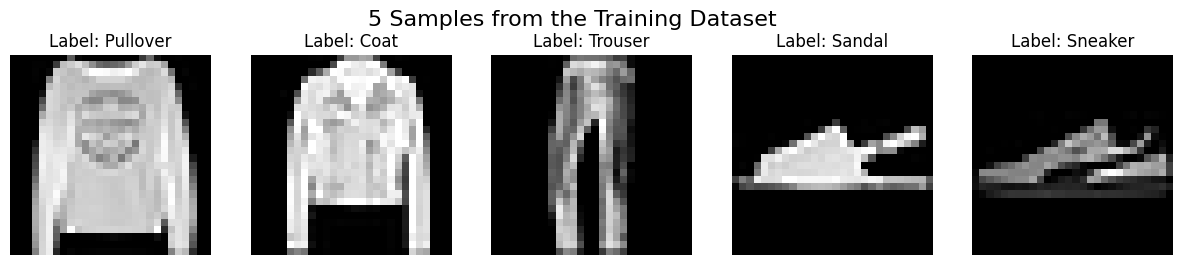

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# normalizng as 0-255 is a huge range, and the gradients will explode if the step is not done.
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(train_set, batch_size=5, shuffle=True)

images, labels = next(iter(loader))
classes = train_set.classes

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i] / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    axes[i].imshow(np.transpose(npimg, (1, 2, 0)).squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {classes[labels[i]]}")
    axes[i].axis('off')
plt.suptitle("5 Samples from the Training Dataset", fontsize=16)
plt.show()

##The Golden Rules Pipeline
Here we define the core training loop and apply the Golden Rules of NN training.

**Note on Data:** I am using 15,000 samples from FashionMNIST. This is large enough for a real experiment, also small enough to check overfitting with such complex model.

Normalizing is also critical here, as 0-255 is a huge range and gradients will explode if this step is not done.

* **Rule 1:** Sanity check. Using one batch to overfit and check if we get 100% accuracy.

* **Rule 2:** Establish a baseline. Run the simple model for 5 epochs. Most probably it will underfit due to the 4-neuron bottleneck mentioned before.

* **Rule 3:** Reduce Bias. Train the very complex model for 30 epochs and see whether the model will overfit. We should notice a huge gap between Train and Test accuracy.

* **Rule 4:** Reduce Variance. Trying different solutions by combining L1 and L2 with Dropouts on the SAME complex architecture to fix the overfitting.

* **Final Step:** Evaluating models, choosing the best one, and printing the evaluation matrix in a shape of a dataframe to be better looking.

### **Note that these insights were written before the training, so they are what we expect to see, not facts.**

In [38]:
%%writefile train.py
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report
from utils import set_seed, get_logger
from models import SimpleModel, ComplexModel

set_seed(42)
logger = get_logger("GoldenRules")

# using gpu for fatser traininng
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# normalizng as 0-255 is a huge range, and the gradients will explode if the step is not done.
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Using 15,000 samples (25% of dataset). Large enough for a real experiment,
# but small enough to force overfitting in 20 epochs.
subset_indices = torch.randperm(len(full_train_set))[:15000]
train_set = Subset(full_train_set, subset_indices)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            running_loss += loss.item()
            _, pred = out.max(1)
            total += lbls.size(0)
            correct += pred.eq(lbls).sum().item()
    return running_loss / len(loader), correct / total

def train_loop(model, optimizer, criterion, epochs, phase_name, l1_lambda=0.0):
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            if l1_lambda > 0:
                loss += l1_lambda * sum(p.abs().sum() for p in model.parameters())

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        logger.info(f"[{phase_name}] Epoch {epoch+1:02d}/{epochs:02d} - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.4f}")

    return train_losses, test_losses, test_acc

crit = nn.CrossEntropyLoss()
history_dict = {}

# GOLDEN RULES

# first rule is the sanity check, using one batch to overfit and chek if we will get 100% accuracy
logger.info("\n\n--- Phase 1: Sanity Check ---")
sanity_model = ComplexModel().to(device)
opt1 = optim.Adam(sanity_model.parameters(), lr=1e-3)
batch_imgs, batch_lbls = next(iter(train_loader))
batch_imgs, batch_lbls = batch_imgs.to(device), batch_lbls.to(device)
sanity_model.train()
for epoch in range(50):
    opt1.zero_grad()
    out = sanity_model(batch_imgs)
    loss = crit(out, batch_lbls)
    loss.backward()
    opt1.step()
_, preds = out.max(1)
logger.info(f"Sanity Check Accuracy on 1 batch: {preds.eq(batch_lbls).sum().item() / batch_lbls.size(0):.4f}")


# second rule run a simple model with few epochs, most prop it will underfit
logger.info("\n\n--- Phase 2: Baseline (Underfitting) ---")
simple = SimpleModel().to(device)
opt2 = optim.Adam(simple.parameters(), lr=1e-3)
h_train, h_test, _ = train_loop(simple, opt2, crit, epochs=5, phase_name="Baseline")
history_dict['baseline'] = {'train': h_train, 'test': h_test}


# third rule train a very complex model and see whether the model will overfit or not
logger.info("\n\n--- Phase 3: Reduce Bias (Overfitting) ---")
complex_model = ComplexModel(use_dropout=False).to(device)
opt3 = optim.Adam(complex_model.parameters(), lr=1e-3)
# 30 epochs to clearly show train accuracy vs test accuracy gap
h_train, h_test, _ = train_loop(complex_model, opt3, crit, epochs=30, phase_name="Overfit")
history_dict['overfit'] = {'train': h_train, 'test': h_test}

# fourth trying diff soluctions combining L1/L2 with dropouts on the SAME complex model
logger.info("\n\n--- Phase 4: Reduce Variance (Testing 5 Strategies) ---")
reg_epochs = 40

# 1. L2 Only
logger.info("Trying L2 Only...")
model_l2 = ComplexModel(use_dropout=False).to(device)
opt_l2 = optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-4)
h_train_l2, h_test_l2, acc_l2 = train_loop(model_l2, opt_l2, crit, epochs=reg_epochs, phase_name="L2_Only")
history_dict['l2'] = {'train': h_train_l2, 'test': h_test_l2}

# 2. L1 Only
logger.info("\nTrying L1 Only...")
model_l1 = ComplexModel(use_dropout=False).to(device)
opt_l1 = optim.Adam(model_l1.parameters(), lr=1e-3)
h_train_l1, h_test_l1, acc_l1 = train_loop(model_l1, opt_l1, crit, epochs=reg_epochs, phase_name="L1_Only", l1_lambda=1e-5)
history_dict['l1'] = {'train': h_train_l1, 'test': h_test_l1}

# 3. Dropout (0.5) Only
logger.info("\nTrying Dropout (0.5) Only...")
model_drop5 = ComplexModel(use_dropout=True).to(device)
model_drop5.dropout = nn.Dropout(0.5)
opt_drop5 = optim.Adam(model_drop5.parameters(), lr=1e-3)
h_train_drop5, h_test_drop5, acc_drop5 = train_loop(model_drop5, opt_drop5, crit, epochs=reg_epochs, phase_name="Drop_0.5")
history_dict['drop_5'] = {'train': h_train_drop5, 'test': h_test_drop5}

# 4. L2 + Dropout (0.4)
logger.info("\nTrying L2 + Dropout (0.4)...")
model_l2_drop4 = ComplexModel(use_dropout=True).to(device)
model_l2_drop4.dropout = nn.Dropout(0.4)
opt_l2_drop4 = optim.Adam(model_l2_drop4.parameters(), lr=1e-3, weight_decay=1e-5)
h_train_l2_drop4, h_test_l2_drop4, acc_l2_drop4 = train_loop(model_l2_drop4, opt_l2_drop4, crit, epochs=reg_epochs, phase_name="L2+Drop_0.4")
history_dict['l2_drop4'] = {'train': h_train_l2_drop4, 'test': h_test_l2_drop4}

# 5. L1 + Dropout (0.4)
logger.info("\nTrying L1 + Dropout (0.4)...")
model_l1_drop4 = ComplexModel(use_dropout=True).to(device)
model_l1_drop4.dropout = nn.Dropout(0.4)
opt_l1_drop4 = optim.Adam(model_l1_drop4.parameters(), lr=1e-3)
h_train_l1_drop4, h_test_l1_drop4, acc_l1_drop4 = train_loop(model_l1_drop4, opt_l1_drop4, crit, epochs=reg_epochs, phase_name="L1+Drop_0.4", l1_lambda=1e-5)
history_dict['l1_drop4'] = {'train': h_train_l1_drop4, 'test': h_test_l1_drop4}


# final step is evaluating models and choosing best one
logger.info("\n\n--- Phase 5: Selection & DataFrame Evaluation ---")
# Comparing all 5 models
best_acc = max(acc_l2, acc_l1, acc_drop5, acc_l2_drop4, acc_l1_drop4)

if best_acc == acc_l2:
    best_model, model_name = model_l2, "L2 Only Model"
elif best_acc == acc_l1:
    best_model, model_name = model_l1, "L1 Only Model"
elif best_acc == acc_drop5:
    best_model, model_name = model_drop5, "Dropout (0.5) Only Model"
elif best_acc == acc_l2_drop4:
    best_model, model_name = model_l2_drop4, "L2 + Dropout (0.4) Model"
else:
    best_model, model_name = model_l1_drop4, "L1 + Dropout (0.4) Model"

logger.info(f"Selected {model_name} with Test Acc: {best_acc:.4f}")

# print evaluation matrix in a shape of a dataframe to be a better looking
best_model.eval()
all_preds, all_lbls = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = best_model(imgs.to(device))
        all_preds.extend(out.max(1)[1].cpu().numpy())
        all_lbls.extend(lbls.numpy())

report_dict = classification_report(all_lbls, all_preds, target_names=test_set.classes, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
logger.info("\n\nFull Evaluation Matrix DataFrame:\n" + df_report.round(4).to_markdown())

torch.save(history_dict, "history.pt")

Overwriting train.py


## Running the Experiment
Using GPU for faster training, run the pipeline and track the logger outputs to see if what we expected before will happen.

In [39]:
!python train.py

2026-03-03 05:49:55,128 - INFO - 

--- Phase 1: Sanity Check ---
2026-03-03 05:49:55,666 - INFO - Sanity Check Accuracy on 1 batch: 1.0000
2026-03-03 05:49:55,666 - INFO - 

--- Phase 2: Baseline (Underfitting) ---
2026-03-03 05:50:00,153 - INFO - [Baseline] Epoch 01/05 - Train Loss: 1.2922 - Train Acc: 0.5703 - Test Loss: 0.7902 - Test Acc: 0.7182
2026-03-03 05:50:05,451 - INFO - [Baseline] Epoch 02/05 - Train Loss: 0.6919 - Train Acc: 0.7540 - Test Loss: 0.6347 - Test Acc: 0.7692
2026-03-03 05:50:10,023 - INFO - [Baseline] Epoch 03/05 - Train Loss: 0.5912 - Train Acc: 0.7927 - Test Loss: 0.5746 - Test Acc: 0.7932
2026-03-03 05:50:14,692 - INFO - [Baseline] Epoch 04/05 - Train Loss: 0.5364 - Train Acc: 0.8117 - Test Loss: 0.5407 - Test Acc: 0.8086
2026-03-03 05:50:20,154 - INFO - [Baseline] Epoch 05/05 - Train Loss: 0.5019 - Train Acc: 0.8245 - Test Loss: 0.5173 - Test Acc: 0.8132
2026-03-03 05:50:20,154 - INFO - 

--- Phase 3: Reduce Bias (Overfitting) ---
2026-03-03 05:50:24,881 - I

##Visualizing the Results
Here we plot the Train Loss vs Test Loss for all phases to clearly see the learning curves, the overfitting gap, and how regularization fixed it.

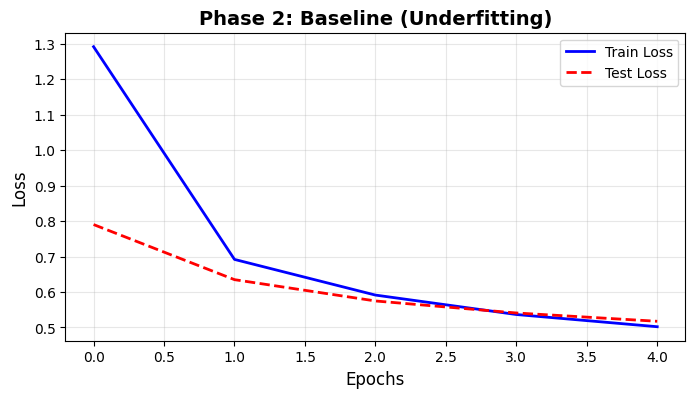

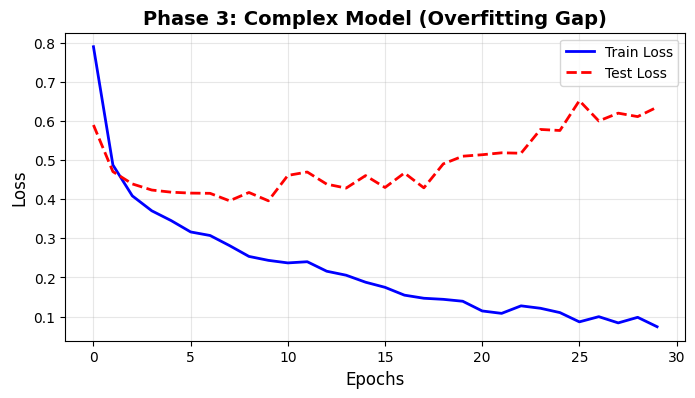

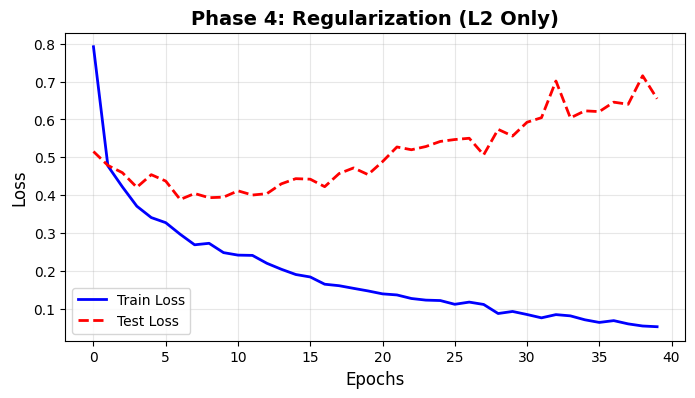

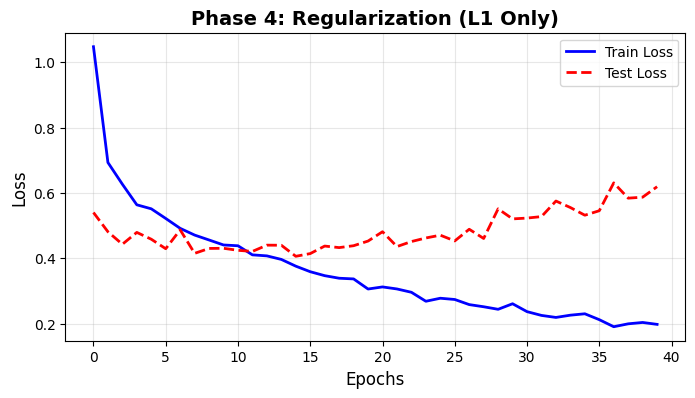

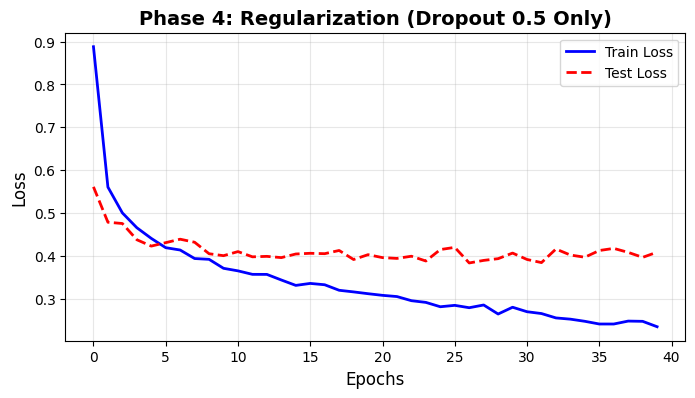

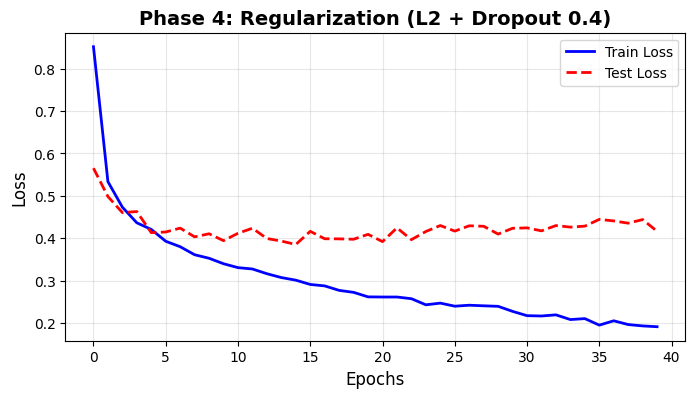

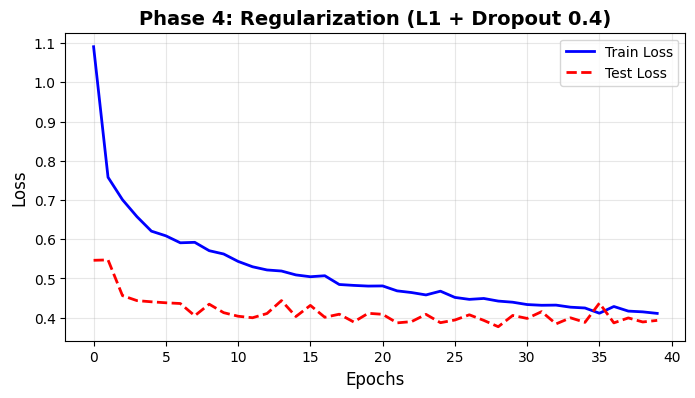

In [40]:
import torch
import matplotlib.pyplot as plt

history = torch.load("history.pt", weights_only=True)

phases_to_plot = [
    ('baseline', 'Phase 2: Baseline (Underfitting)'),
    ('overfit', 'Phase 3: Complex Model (Overfitting Gap)'),
    ('l2', 'Phase 4: Regularization (L2 Only)'),
    ('l1', 'Phase 4: Regularization (L1 Only)'),
    ('drop_5', 'Phase 4: Regularization (Dropout 0.5 Only)'),
    ('l2_drop4', 'Phase 4: Regularization (L2 + Dropout 0.4)'),
    ('l1_drop4', 'Phase 4: Regularization (L1 + Dropout 0.4)')
]

for phase_key, title in phases_to_plot:
    plt.figure(figsize=(8, 4))
    plt.plot(history[phase_key]['train'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(history[phase_key]['test'], label='Test Loss', color='red', linestyle='--', linewidth=2)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

#FINAL THOUGHTS


## Observation & Conclusion

After finishing the training, I decided to leave these results and comment on them. I will also mention the graphs as they helped me a lot to understand the numbers and easily track them.

* **Baseline (Phase 2):** Underfitting was very clear. The simple 4-neuron model showed that we will need more complex model to get better results.

* **Overfitting (Phase 3):**  while the Train Loss drops to almost zero, the Test Loss starts to fly up after a few epochs, showing a massive generalization gap. This is even more obvious when looking at the Loss Graph.

* **L1 & L2 Only:** At first, I just tried L1 and L2 regularization separately, but I didn't find much difference compared to the overfitted model.

* **Dropout (0.5) Only:** After trying Dropout, I found better generalization. Although the model didn't achieve higher test accuracy, it had a much lower generalization error (the gap between Train and Test was closed significantly as shown in the plot).

* **Combining Methods (L1/L2 + Dropout):** I was curious to combine both methods and see what would happen. I also had the chance to test some variations of epochs (running for 40 epochs) to see their effect.

    * **L2 + Dropout (0.4):** This was the winning model! It achieved the highest Test Accuracy (87.42%) and showed a very healthy learning curve with a great generalization.

    * **L1 + Dropout (0.4):** This model showed a very interesting phenomenon.

**Why is the Test Loss lower than the Train Loss in L1 + Dropout?**

I noticed  that the Test Loss is consistently *lower* than the Train Loss at the L1 + Dropout logs and graphs. so I searched the reason and here is what I've found:

1.  **Dropout Behavior:** Dropout is active during Training (randomly dropping 40% of neurons, making it harder for the network to predict and causing higher train loss). However, Dropout is turned OFF during Testing. The test set gets the full power of the ensemble network, leading to better predictions and lower loss.

2.  **L1 Penalty Calculation:** During training, the L1 penalty is added to the training loss. During testing/evaluation, this penalty is **NOT** added to the loss calculation.

In my opinion, Dropout did the best job at generalization, and it made a huge difference. Without it, the other regularization techniques wouldn't have been the best choice on their own for this specific complex architecture, and this is even obvious when we take a closer look at the Dropout only loss cure, it has a great generalization by its own.

